<a href="https://colab.research.google.com/github/laramalkawi81-ops/DS230-Instacart-Project/blob/main/01_Data%20Loading%20%26%20Initial%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS230 Final Project – File 1
## Data Loading & Initial Exploratory Data Analysis (EDA)

This notebook focuses on loading the Instacart dataset, verifying data integrity,
and performing initial exploratory analysis to understand the structure,
distributions, and missing values.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content


drive  sample_data


In [ ]:
!ls /content/drive


MyDrive


In [ ]:
!ls /content/drive/MyDrive


'Colab Notebooks'   DS230_Final_Project   instacart_data


In [ ]:
!ls /content/drive/MyDrive/instacart_data



instacart_data


In [ ]:
!ls /content/drive/MyDrive/instacart_data


instacart_data


In [ ]:
import os

os.listdir('/content/drive/MyDrive')


['Colab Notebooks', 'DS230_Final_Project', 'instacart_data']

In [ ]:
os.listdir('/content/drive/MyDrive/instacart_data/instacart_data')


['departments.csv',
 'aisles.csv',
 'order_products__prior.csv',
 'order_products__train.csv',
 'products.csv',
 'orders.csv']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive


'Colab Notebooks'   DS230_Final_Project   instacart_data


In [ ]:
import pandas as pd
import numpy as np
import os

DATA_PATH = '/content/drive/MyDrive/instacart_data/instacart_data'


orders = pd.read_csv(os.path.join(DATA_PATH, 'orders.csv'))
products = pd.read_csv(os.path.join(DATA_PATH, 'products.csv'))
order_products_prior = pd.read_csv(os.path.join(DATA_PATH, 'order_products__prior.csv'))
order_products_train = pd.read_csv(os.path.join(DATA_PATH, 'order_products__train.csv'))
aisles = pd.read_csv(os.path.join(DATA_PATH, 'aisles.csv'))
departments = pd.read_csv(os.path.join(DATA_PATH, 'departments.csv'))


In [ ]:
order_products_prior.head()


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [ ]:
print("Orders shape:", orders.shape)
print("Products shape:", products.shape)
print("Aisles shape:", aisles.shape)
print("Departments shape:", departments.shape)


Orders shape: (3421083, 7)
Products shape: (49688, 4)
Aisles shape: (134, 2)
Departments shape: (21, 2)


In [ ]:
orders.head()


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0



In this step, we load all the main CSV files provided in the dataset.
We inspect the size and structure of each table to understand the available information and how the tables can be joined late

In [ ]:
orders.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB


In [ ]:
orders.describe()


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


In [ ]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [ ]:
products.describe()

,product_id,aisle_id,department_id
count,49688.000000,49688.000000,49688.000000
mean,24844.500000,67.769582,11.728687
std,14343.834425,38.316162,5.850410
min,1.000000,1.000000,1.000000
25%,12422.750000,35.000000,7.000000
50%,24844.500000,69.000000,13.000000
75%,37266.250000,100.000000,17.000000
max,49688.000000,134.000000,21.000000


In [ ]:
print(orders.head())
print(products.head())


   order_id  user_id eval_set  order_number  order_dow  order_hour_of_day  \
0   2539329        1    prior             1          2                  8   
1   2398795        1    prior             2          3                  7   
2    473747        1    prior             3          3                 12   
3   2254736        1    prior             4          4                  7   
4    431534        1    prior             5          4                 15   

   days_since_prior_order  
0                     NaN  
1                    15.0  
2                    21.0  
3                    29.0  
4                    28.0  
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni

### Dataset Overview

- **orders**: Contains user order history including order timing and frequency.
- **order_products__prior**: Links products to prior orders with reorder information.
- **products / aisles / departments**: Metadata describing products and categories.


Missing Values

In [ ]:
orders.isnull().sum()


,0
order_id,0
user_id,0
eval_set,0
order_number,0
order_dow,0
order_hour_of_day,0
days_since_prior_order,206209


visualization:

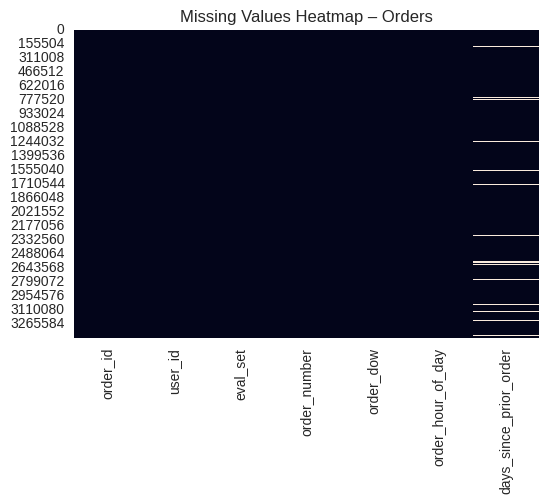

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(orders.isnull(), cbar=False)
plt.title("Missing Values Heatmap – Orders")
plt.show()


We observe missing values mainly in `days_since_prior_order`,
which is expected for a user's first order.


Simple numerical distributions

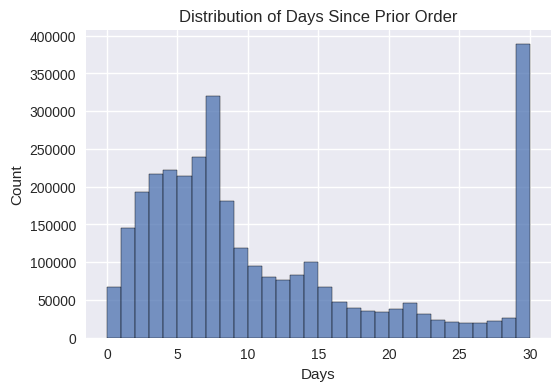

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(orders['days_since_prior_order'].dropna(), bins=30)
plt.title("Distribution of Days Since Prior Order")
plt.xlabel("Days")
plt.ylabel("Count")
plt.show()


Temporal variables

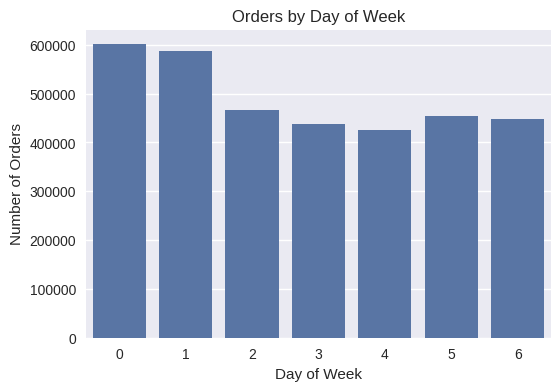

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='order_dow', data=orders)
plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()


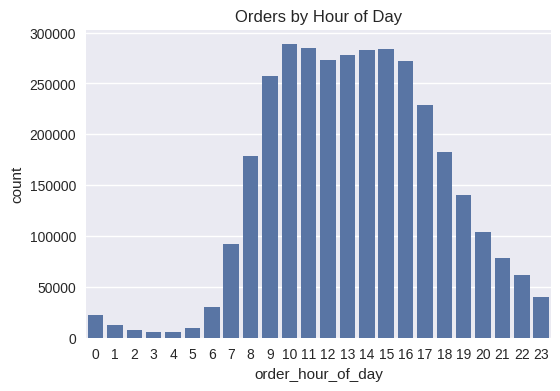

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='order_hour_of_day', data=orders)
plt.title("Orders by Hour of Day")
plt.show()


Simple EDA for products

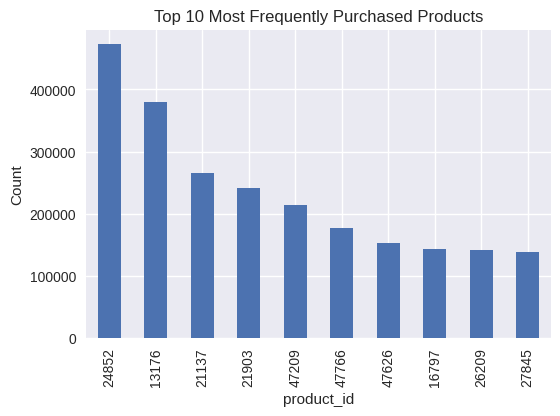

In [ ]:
top_products = order_products_prior['product_id'].value_counts().head(10)

plt.figure(figsize=(6,4))
top_products.plot(kind='bar')
plt.title("Top 10 Most Frequently Purchased Products")
plt.ylabel("Count")
plt.show()



Summary of Initial Findings

- The dataset contains multiple relational tables that require joins.
- Missing values appear mainly in `days_since_prior_order`.
- Ordering behavior shows clear daily and hourly patterns.
- Product purchase frequency is highly skewed toward a small subset of products.

Further cleaning, preprocessing, and feature engineering will be handled in File 2.